In [1]:
%load_ext autoreload
%autoreload 2
%xmode verbose

Exception reporting mode: Verbose


In [5]:
import pandas
data = pandas.read_csv('exoplanet_data.csv')
data = data.drop_duplicates(subset = 'pl_name')
data = data.drop_duplicates(subset = 'pl_rade')
data.to_csv('exoplanet_data.csv', index = False)

In [6]:
import pandas
import matplotlib.pyplot as plot
import numpy

data = pandas.read_csv('exoplanet_data.csv')

data['radius'] = data['pl_rade']
data['mass'] = data['pl_bmasse']
data = data[['radius', 'mass']].dropna().reset_index(drop = True)
data = data.sort_values('radius').reset_index(drop = True)
data = data.reset_index(drop = True)
data

,radius,mass
0,0.580000,3.000000
1,0.699000,0.633000
2,0.705000,0.290131
3,0.759000,0.440000
4,0.788000,0.388000
...,...,...
432,23.090540,273.333800
433,23.538859,375.037520
434,24.660000,5403.000000
435,33.600000,6356.000000


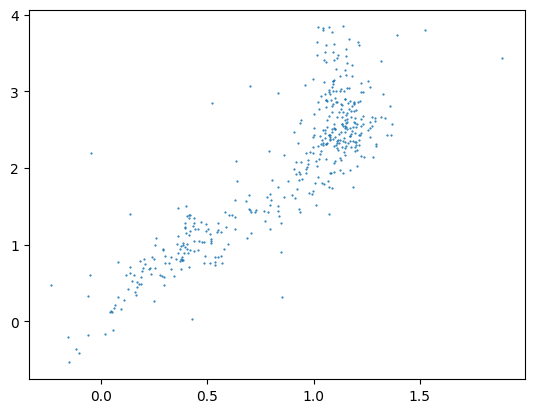

In [8]:
x = data['radius']
y = data['mass']

# mask = x < 30
# x, y = x[mask], y[mask]
#
# mask = y < 4132.70
# x, y = x[mask], y[mask]

x, y = x.reset_index(drop = True), y.reset_index(drop = True)

x = numpy.log10(x)
y = numpy.log10(y)

_, unique_indices = numpy.unique(x, return_index = True)
x, y = x[unique_indices], y[unique_indices]
plot.scatter(x, y, s = 0.3)
# plot.loglog()
plot.show()

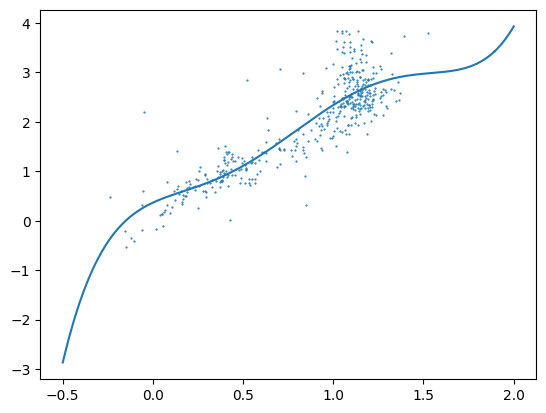

In [20]:
from scipy.interpolate import UnivariateSpline

spline = UnivariateSpline(x, y, k = 5, s = 100)

x_smooth = numpy.linspace(-0.5, 2, 10000)
y_smooth = spline(x_smooth)

plot.scatter(x, y, s = 0.3)
plot.plot(x_smooth, y_smooth)
plot.show()

from LogRMSpline import LogRMSpline
spline = LogRMSpline(spline, x, y)

# spline.cap_min(-0.133003300330033, 0.0006803890584116942)
# spline.cap_max(1.7833183318331833, 4.042209472198081)

In [21]:
import dill

with open('radius_mass_spline.pkl', 'wb') as file:
    dill.dump(spline, file)

Log Min: -0.5, -2.8685593277065653
Log Max: 2.0, 3.9299799682082206
Log Spread: 0.4527783778773737


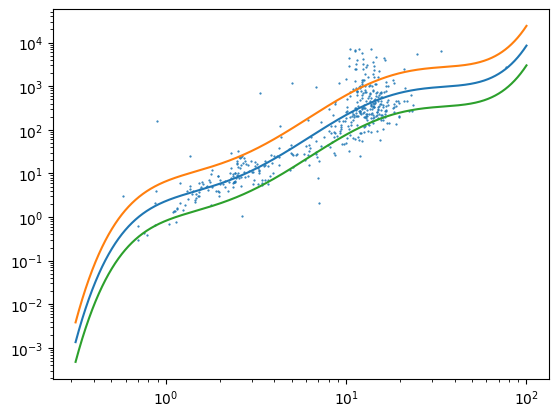

In [22]:
import dill
import matplotlib.pyplot as plot
import numpy

with open('radius_mass_spline.pkl', 'rb') as file:
    spline = dill.load(file)

x_smooth = numpy.linspace(-0.5, 2, 10000)
y_smooth = spline(x_smooth)

print(f'Log Min: {x_smooth[numpy.argmin(y_smooth)]}, {numpy.min(y_smooth)}')
print(f'Log Max: {x_smooth[numpy.argmax(y_smooth)]}, {numpy.max(y_smooth)}')
print(f'Log Spread: {spline.spread}')

# y_smooth[x_smooth < x_smooth[numpy.argmin(y_smooth)]] = y_smooth[numpy.argmin(y_smooth)]
# y_smooth[x_smooth > x_smooth[numpy.argmax(y_smooth)]] = y_smooth[numpy.argmax(y_smooth)]

# plot.scatter(x, y, s = 0.3)
# plot.plot(x_smooth, y_smooth)
# plot.plot(numpy.linspace(numpy.min(x_smooth), numpy.max(x_smooth), 10), numpy.linspace(numpy.log10(4130), numpy.log10(4130), 10))

plot.plot(numpy.power(10, x_smooth), numpy.power(10, y_smooth))
plot.plot(numpy.power(10, x_smooth), numpy.power(10, y_smooth + spline.spread))
plot.plot(numpy.power(10, x_smooth), numpy.power(10, y_smooth - spline.spread))
plot.scatter(numpy.power(10, x), numpy.power(10, y), s = 0.3)

plot.loglog()
# plot.xlim(0, 25)
# plot.yscale('log')
plot.show()